In [1]:
import os
from xspec import *
import xspec
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from decimal import Decimal
from scipy import optimize, stats
from iminuit import Minuit
from scipy.stats import chi2 as chi2_scipy


Xset.allowPrompting = False # keeps pyxspec from hanging, waiting for a response to a prompt

# GOAL: to fit spectra in a window around the line. Use XSpec to fit

Here I load the data 

In [2]:
AllData.clear()
path="/Users/marcotaoso/Documents/2024/eROSITA/FromJorge/LMC_test_3deg/srctoolout_000_SourceProducts_00001_cheesemask_circle_masked/"
#filespectrumTM1=path+"srctoolout_120_SourceSpec_00001.fits"
filespectrumTM1=path+"Rebining_2/srctoolout_120_SourceSpec_00001_2.grp"
fileRMFTM1=path+"srctoolout_120_RMF_00001.fits"
fileARFTM1=path+"srctoolout_120_ARF_00001.fits"
#
#filespectrumTM2=path+"srctoolout_220_SourceSpec_00001.fits"
filespectrumTM2=path+"Rebining_2/srctoolout_220_SourceSpec_00001_2.grp"
fileRMFTM2=path+"srctoolout_220_RMF_00001.fits"
fileARFTM2=path+"srctoolout_220_ARF_00001.fits"
#
#filespectrumTM3=path+"srctoolout_320_SourceSpec_00001.fits"
filespectrumTM3=path+"Rebining_2/srctoolout_320_SourceSpec_00001_2.grp"
fileRMFTM3=path+"srctoolout_320_RMF_00001.fits"
fileARFTM3=path+"srctoolout_320_ARF_00001.fits"
#
#filespectrumTM4=path+"srctoolout_420_SourceSpec_00001.fits"
filespectrumTM4=path+"Rebining_2/srctoolout_420_SourceSpec_00001_2.grp"
fileRMFTM4=path+"srctoolout_420_RMF_00001.fits"
fileARFTM4=path+"srctoolout_420_ARF_00001.fits"
#
#filespectrumTM5=path+"srctoolout_520_SourceSpec_00001.fits"
filespectrumTM5=path+"Rebining_2/srctoolout_520_SourceSpec_00001_2.grp"
fileRMFTM5=path+"srctoolout_520_RMF_00001.fits"
fileARFTM5=path+"srctoolout_520_ARF_00001.fits"
#
#filespectrumTM6=path+"srctoolout_620_SourceSpec_00001.fits"
filespectrumTM6=path+"Rebining_2/srctoolout_620_SourceSpec_00001_2.grp"
fileRMFTM6=path+"srctoolout_620_RMF_00001.fits"
fileARFTM6=path+"srctoolout_620_ARF_00001.fits"
#
#filespectrumTM7=path+"srctoolout_720_SourceSpec_00001.fits"
filespectrumTM7=path+"Rebining_2/srctoolout_720_SourceSpec_00001_2.grp"
fileRMFTM7=path+"srctoolout_720_RMF_00001.fits"
fileARFTM7=path+"srctoolout_720_ARF_00001.fits"
#
#Put here the TM you want to use 
#
vfilespectrum = [filespectrumTM6]#,filespectrumTM2,filespectrumTM3,filespectrumTM4,filespectrumTM6]
vfileRMF = [fileRMFTM6]#,fileRMFTM2,fileRMFTM3,fileRMFTM4,fileRMFTM6]
vfileARF = [fileARFTM6]#,fileARFTM2,fileARFTM3,fileARFTM4,fileARFTM6]
#
#LOAD DATA
#
AllData.clear()
for plot_grp in range (0,len(vfilespectrum)):
    #print("plot_grp ",plot_grp)
    Spectrum(vfilespectrum[plot_grp])
    AllData(plot_grp+1).response = vfileRMF[plot_grp]
    AllData(plot_grp+1).response.arf = vfileARF[plot_grp]

AllData.show()


 response file  read skipped


Error: cannot read response file srctoolout_620_RMF_00001.fits



1 spectrum  in use
 
Spectral Data File: /Users/marcotaoso/Documents/2024/eROSITA/FromJorge/LMC_test_3deg/srctoolout_000_SourceProducts_00001_cheesemask_circle_masked/Rebining_2/srctoolout_620_SourceSpec_00001_2.grp  Spectrum 1
Net count rate (cts/s) for Spectrum:1  1.532e+00 +/- 4.050e-03
 Assigned to Data Group 1 and Plot Group 1
  Noticed Channels:  1-512
  Telescope: eROSITA Instrument: TM6  Channel Type: PI
  Exposure Time: 9.34e+04 sec
 Using fit statistic: chi
 No response loaded.

***Warning!  One or more spectra are missing responses,
               and are not suitable for fit.
Response successfully loaded.
Arf successfully loaded.

1 file 1 spectrum 
Spectrum 1  Spectral Data File: /Users/marcotaoso/Documents/2024/eROSITA/FromJorge/LMC_test_3deg/srctoolout_000_SourceProducts_00001_cheesemask_circle_masked/Rebining_2/srctoolout_620_SourceSpec_00001_2.grp
Net count rate (cts/s) for Spectrum:1  1.532e+00 +/- 4.050e-03
 Assigned to Data Group 1 and Plot Group 1
  Noticed Channe

In [3]:
# PLOT of Aeff for various telescopes

#fig, ax = plt.subplots(figsize=(10,6))
#for i in range (0,len(vfileARF)):
#    arf1test = fits.open(vfileARF[i])['SPECRESP']
#    arf1ELOW = arf1test.data.field('ENERG_LO')#keV
#    arf1EHI = arf1test.data.field('ENERG_HI')#keV
#    arf1Aeff = arf1test.data.field('SPECRESP')#cm2
#    arf1E = (arf1ELOW + arf1EHI)/2.
#    ax.plot(arf1E, arf1Aeff,label='TM')
#ax.set_xlabel('Energy (keV)')
#ax.set_ylabel(r'A_{eff} [cm^2]')
#ax.set_xscale("log")
#ax.set_yscale("log")
#ax.set_xlim((0.8,1.5))
#ax.grid()
#ax.legend()

NOW LOAD the Sigma of EROSITA. At the moment I take the FWHM from https://erosita.mpe.mpg.de/edr/eROSITATechnical/calibration.html
Computing \sigma=FWHM/2.355 I find that \sigma ranges from [33,72] eV and E/sigma = [34,139] for E ranging from 1 to 10 keV. 
This is >> sigmav = c/v = 1360 for v=220 km/s.
Larger than intrinsic/Doppler width of astro lines???

In [4]:
data = np.loadtxt("/Users/marcotaoso/Documents/2024/eROSITA/FromJorge/sigma/Energy_width.txt",delimiter=",")
vE = data[:,0]
vFWHM = data[:,1]*1e-3 #keV
vsigma = vFWHM/(2.355)

Fix the energy of the DM line and select data

In [5]:
# I do not consider eROSITA data outside this range
Eallmin = 0.3
Eallmax = 9.

Eline = 1.312 #0.842 $6.266 $4.771

sigma = np.interp(Eline,vE,vsigma)
print("Eline ",Eline," sigma ",sigma)
Emin= Eline - 5*sigma
Emax= Eline + 5*sigma
if(Emin<Eallmin):
    Emin=Eallmin
if(Emax>Eallmax):
    Emax=Eallmax
print("Emin ",Emin," Emax ",Emax)
str_range = "**-"+str(round(Emin, 4))+",,"+str(round(Emax, 4))+"-**"
print(str_range)
AllData.ignore(str_range)


Plot.commands = ()
Plot.xAxis = "keV"
Plot("data")
#ax.clear()
# Compute number of E bins, assumig it is the same for all TM
NEbins = len(np.asarray(Plot.x(1)))
print("NEbins ",NEbins)
venergies = np.zeros((len(vfilespectrum), NEbins))
vedeltas = np.zeros((len(vfilespectrum), NEbins))
vrates = np.zeros((len(vfilespectrum), NEbins))
verrors = np.zeros((len(vfilespectrum), NEbins))
for i in range (0,len(vfilespectrum)):
    plot_grp = i + 1 # so that it starts with 1
    energiesTMi = np.asarray(Plot.x(plot_grp))
    edeltasTMi = np.asarray(Plot.xErr(plot_grp))
    ratesTMi = np.asarray(Plot.y(plot_grp))
    errorsTMi = np.asarray(Plot.yErr(plot_grp))
    venergies[i] = energiesTMi 
    vedeltas[i] = edeltasTMi 
    vrates[i] = ratesTMi 
    verrors[i] = errorsTMi 
    print("***************")
    print("Selected values ",np.min(energiesTMi)," ",np.max(energiesTMi)," Nbins ",len(energiesTMi))
    print("***************")
    channelmin = AllData(plot_grp).noticed[0] -1
    channelmax = AllData(plot_grp).noticed[-1]
    #print("channelmin/max ",channelmin," ",channelmax)
    #
    SpectrumOpen = fits.open(vfilespectrum[plot_grp-1])['SPECTRUM']
    counts_TMi = SpectrumOpen.data.field('COUNTS')#
    channel_TMi = SpectrumOpen.data.field('CHANNEL')#
    exposure_TMi=fits.getval(vfilespectrum[plot_grp-1],"exposure", ext=1)
    RMFOpen = fits.open(vfileRMF[plot_grp-1])['EBOUNDS']
    Emin_data_TMi = RMFOpen.data.field('E_MIN')#keV
    Emax_data_TMi = RMFOpen.data.field('E_MAX')#keV
    Eave_data_TMi = (Emin_data_TMi+Emax_data_TMi)/2.
    DeltaE_data_TMi = Emax_data_TMi-Emin_data_TMi
    DeltaE_ana_TMi = DeltaE_data_TMi[channelmin:channelmax]
    Eave_ana_TMi = Eave_data_TMi[channelmin:channelmax]
    channel_ana_TMi = channel_TMi[channelmin:channelmax]
    counts_ana_TMi = counts_TMi[channelmin:channelmax]
    print("Min Max counts ",np.min(counts_ana_TMi)," ",np.max(counts_ana_TMi))


Eline  1.312  sigma  0.031675073251612784
Emin  1.153624633741936  Emax  1.470375366258064
**-1.1536,,1.4704-**
Plot command list is now empty
NEbins  20
***************
Selected values  1.1668291091918945   1.46138596534729  Nbins  20
***************
    86 channels (1-86) ignored in spectrum #     1
   406 channels (107-512) ignored in spectrum #     1

Min Max counts  698   1169


In [6]:
print("sigma ",sigma)
print("DeltaE ",vedeltas[0]*2)
print("Sigma/DeltaE ",sigma/(vedeltas[0]*2))

sigma  0.031675073251612784
DeltaE  [0.01493597 0.01499617 0.01505637 0.0151161  0.0151763  0.0152359
 0.01529574 0.01535559 0.01541483 0.01547456 0.01553404 0.01559353
 0.01565254 0.01571178 0.01577091 0.01582992 0.01588857 0.01594746
 0.01600623 0.01606464]
Sigma/DeltaE  [2.12072417 2.11221073 2.10376536 2.09545336 2.08714121 2.07897606
 2.07084228 2.06277189 2.05484361 2.04691297 2.03907461 2.03129604
 2.02363825 2.01600738 2.00844903 2.00096221 1.99357587 1.98621417
 1.97892137 1.97172583]


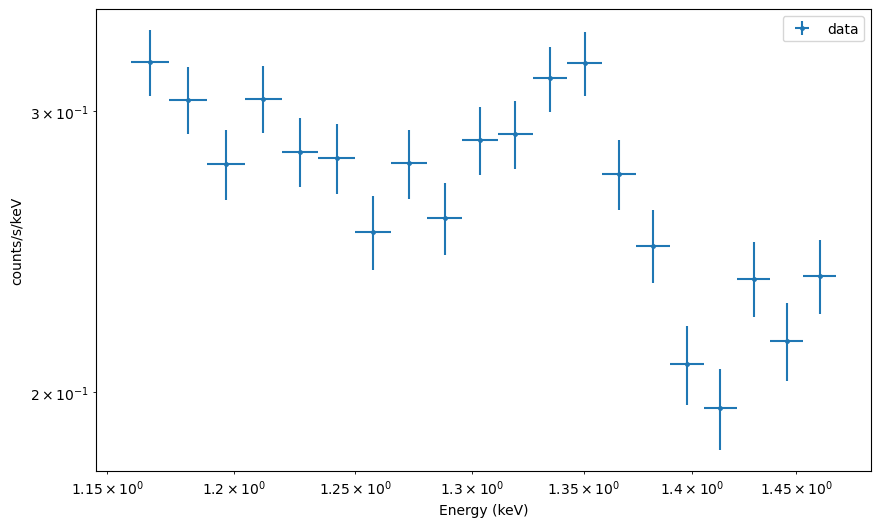

In [7]:
#ax.clear()
fig, ax = plt.subplots(figsize=(10,6))
for i in range (0,len(vfilespectrum)):
    ax.errorbar(venergies[i], vrates[i], xerr=vedeltas[i],yerr=verrors[i],fmt='.',markersize='5',label='data')
#ax.errorbar(energies, rates, xerr=edeltas,yerr=errors,fmt='.',markersize='5',label='data')
#ax.axhline(y=10)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

Now I consider the Astro and Internal Background lines falling into the energy range +- 7 sigma. At the end I define arrays containing the position of the lines and the min and max values inside which they can fluctuate in the fit


In [8]:
EminL = Eline - 7*sigma
EmaxL = Eline + 7*sigma
if(EminL<Eallmin):
    EminL = Eallmin
if(EmaxL>Eallmax):
    EmaxL = Eallmax

data = np.loadtxt("/Users/marcotaoso/Documents/2024/eROSITA/IB_FWC/IBLines.txt",skiprows=0)
IBenergy = data[:,0]
IBenergymin = data[:,1]
IBenergymax = data[:,2]
data = np.loadtxt("/Users/marcotaoso/Documents/2024/eROSITA/AstroLines/AstroLines.txt",skiprows=0)
Aenergy = data[:,0]
Aenergymin = data[:,1]
Aenergymax = data[:,2]
#print(Aenergy," ",IBenergy)
#print(len(Aenergy)," ",len(IBenergy))
IBidx = np.where( (IBenergy > EminL ) & (IBenergy < EmaxL ) )
Aidx = np.where( (Aenergy > EminL ) & (Aenergy < EmaxL ) )
IBLine = IBenergy[IBidx]
IBLinemin = IBenergymin[IBidx]
IBLinemax = IBenergymax[IBidx]


ALine = Aenergy[Aidx]
#ALinemin = Aenergymin[Aidx]
#ALinemax = Aenergymax[Aidx]
# SET HERE VARIATION OF ASTRO LINE
AstroEl = 0.005;
ALinemin = ALine - AstroEl
ALinemax = ALine + AstroEl


IBn = len(IBLine)
An = len(ALine)
#
# For this model avoid Astro lines
#
IBALine = IBLine.copy()
IBALinemin = IBLinemin.copy()
IBALinemax = IBLinemax.copy()
IBAn = IBn
idx = np.argsort(IBALine)
IBALine = IBALine[idx]
IBALinemin = IBALinemin[idx]
IBALinemax = IBALinemax[idx]
print("Total lines ",IBAn," IB ",IBn," A ",An)
print(IBALine)
print(IBALinemin," ",IBALinemax)

Total lines  1  IB  1  A  0
[1.48585]
[1.47]   [1.5]


FUNCTIONS TO SET LINES TO ZERO AND FIX THEM OR TO FREE THEM

In [9]:
# CLASS TO DEFINE A FUNCTION TO EVALUATE THE TS specified in fit GIVEN A xspec Model model
# with paramers value params, name (gaussian_3, powerlaw,...) params_name and target (norm, LineE,...) params_target

class MTmodel:
    def __init__(self, model, params_name, params_target, fit):
        self.model = model
        self.params_name = params_name
        self.params_target = params_target
        self.fit = fit

        # Precompile fast setters for just the main value (index 0 of .values)
        self._param_fast_setters = [
            self._make_fast_setter(getattr(getattr(model, name), attr))
            for name, attr in zip(params_name, params_target)
        ]

        # Also keep full parameter objects for set_values_all
        self._param_objects = [
            getattr(getattr(model, name), attr)
            for name, attr in zip(params_name, params_target)
        ]

    def _make_fast_setter(self, param_obj):
        def setter(value, param_obj=param_obj):
            #param_obj.values[0] = value
            param_obj.values = value
        return setter

    #set value of parameters
    def set_values(self, params):
        for setter, value in zip(self._param_fast_setters, params):
            setter(float(value))  # direct, fast assignment

    #set value of parameters including upper/lower limits
    def set_values_all(self, params, lowers, uppers):
        for i, param in enumerate(self._param_objects):
            a = float(params[i])
            b = float(lowers[i])
            c = float(uppers[i])
            param.values = [a, 1e-2 * a, b, b, c, c]

    # evaluate TS given paramaters params
    def evaluate_folded(self, params):
        self.set_values(params)
        return self.fit.statistic

    # set a given params_name, params_target to keyfits, i.e. True/False. Relevant for fit with xSpec
    # Careful: my logic is True means is in the fit therefore corresponds to .frozen = False
    def set_frozen(self, keyfits):
        """
        Freeze or unfreeze parameters based on keyfits.
        keyfits[i] == True  → parameter is free (frozen = False)
        keyfits[i] == False → parameter is frozen (frozen = True)
        """
        if len(keyfits) != len(self.params_name):
            raise ValueError("keyfits must be the same length as params_name and params_target")

        for param, keep_free in zip(self._param_objects, keyfits):
            param.frozen = not keep_free  # Invert: True means not frozen

    # return the value of the parameters    
    def get_values(self):
        """Return current values (i.e., param.values[0]) as numpy array."""
        return np.array([param.values[0] for param in self._param_objects])

In [10]:
# Functions working on dictionary

# Given a dictionary model_dic,
# extract all entries as numpy arrays
def Extract_array_dic(model_dic):
    params = []
    lowers = []
    uppers = []
    keyfits = []
    params_name = []
    params_target = []
    for top_key, sub_models in model_dic.items():
        # Skip non-model entries like _structure
        if not isinstance(sub_models, dict):
            continue
        for sub_key, parameters in sub_models.items():
            for paramtarget, param_info in parameters.items():
                params.append(param_info["value"])
                lowers.append(param_info["lower"])
                uppers.append(param_info["upper"])
                keyfits.append(param_info["keyfit"])
                params_name.append(sub_key)     # second-level key (e.g., powerlaw_2)
                params_target.append(paramtarget)     # third-level key (e.g., PhoIndex)

    # Convert everything to NumPy arrays
    params = np.array(params)
    lowers = np.array(lowers)
    uppers = np.array(uppers)
    params_name = np.array(params_name)
    params_target = np.array(params_target)
    keyfits = np.array(keyfits)
    return (params,lowers,uppers,params_name,params_target,keyfits)

In [11]:
# Functions working on numpy arrays

# input arrays defining all the parameters of the model
# output: arrays of parameters entering in the fit (keyfits is True)
def paramfit(params, lowers, uppers , params_name, params_target, keyfits):
    # Create a mask for where keyfits is True
    mask = keyfits == True
    #print(keyfits)
    #print(mask)
    # Apply the mask
    params_out = params[mask]
    lowers_out = lowers[mask]
    uppers_out = uppers[mask]
    params_name_out = params_name[mask]
    params_target_out = params_target[mask]
    keyfits_out = keyfits[mask]
    bounds_out = np.column_stack((lowers_out, uppers_out))
    #print("Values:", params)
    #print("Lowers:", lowers)
    #print("Uppers:", uppers)
    #print("Keyfits:", keyfits)
    #print("Submodel keys:", params_name)
    #print("Param keys:", params_target)
    return (params_out, bounds_out, params_name_out, params_target_out, keyfits_out)

# Select element of params_name, params_target associated to params_name, target_key
# and for that change keyfits to keyfits_value
def change_keyfits(params_name, params_target, keyfits, name_key, target_key, keyfits_value):
    mask = np.logical_and(params_name == name_key, params_target == target_key)
    idx = np.flatnonzero(mask) #True==1
    #print(idx[0]," ",name_key[idx[0]])
    keyfits[idx[0]] = keyfits_value

# For params associated to name_key, target_key change the value to key_value 
def change_param_value(params, params_name, params_target, name_key, target_key, value):
    mask = np.logical_and(params_name == name_key, params_target == target_key)
    idx = np.flatnonzero(mask)
    params[idx[0]] = value

# Return params associated to name_key, target_key
def return_param_value(params, params_name, params_target, name_key, target_key):
    mask = np.logical_and(params_name == name_key, params_target == target_key)
    idx = np.flatnonzero(mask)
    return params[idx[0]]

# Print parameters
def printparam(params, lowers, uppers , params_name, params_target, keyfits):
    for i in range(0,len(params_name)):
        print(params_name[i]," ",params_target[i]," ", params[i]," ", lowers[i]," ", uppers[i]," ", keyfits[i])

Normalization factor (can be useful to define limits of the parameters)

In [12]:
# COMPUTE norm of the line to hit data
# to have an idea of a sensible normalization
# For simplicity choose TM1
arf1test = fits.open(fileARFTM1)['SPECRESP']
arf1ELOW = arf1test.data.field('ENERG_LO')#keV
arf1EHI = arf1test.data.field('ENERG_HI')#keV
arf1Aeff = arf1test.data.field('SPECRESP')#cm2
arf1E = (arf1ELOW + arf1EHI)/2.
Aefftest = np.interp(Eline, arf1E, arf1Aeff)
Ratetest = np.interp(Eline, venergies[0], vrates[0])
normlDMhdata = Ratetest/Aefftest # counts/keV/s/cm2
print("normlDMhdata [counts/keV/s/cm2]",normlDMhdata)
# normlDMhdata2 is the correct normalization to set norm of DM gaussian line to a reasonable value! 
# It has the same units of norm of Gaussian
# See nAPEC_Alll.ipynb
normlDMhdata2 = normlDMhdata*np.sqrt(2*np.pi)*sigma # counts/s/cm2
print("normlDMhdata2 [counts/s/cm2]",normlDMhdata2)

'''
def estimate_local_slope(energies, rates, emin, emax):
    mask = (energies > emin) & (energies < emax) & (rates > 0)
    x = np.log10(energies[mask])
    y = np.log10(rates[mask])
    slope, intercept = np.polyfit(x, y, 1)
    return -slope  # XSPEC uses negative definition

slope1 = estimate_local_slope(venergies[0], vrates[0], Eline - 0.5, Eline)
slope2 = estimate_local_slope(venergies[0], vrates[0], Eline, Eline + 0.5)

upperpl = np.percentile(vrates[0], 95) / Aefftest
lowerpl = np.percentile(vrates[0], 5) / Aefftest
print("Upper PL ",upperpl," Lower PL ",lowerpl)

print("Slope1 ",slope1," Slope2 ",slope2)
'''

normlDMhdata [counts/keV/s/cm2] 0.07908200124816687
normlDMhdata2 [counts/s/cm2] 0.006278923807973559


'\ndef estimate_local_slope(energies, rates, emin, emax):\n    mask = (energies > emin) & (energies < emax) & (rates > 0)\n    x = np.log10(energies[mask])\n    y = np.log10(rates[mask])\n    slope, intercept = np.polyfit(x, y, 1)\n    return -slope  # XSPEC uses negative definition\n\nslope1 = estimate_local_slope(venergies[0], vrates[0], Eline - 0.5, Eline)\nslope2 = estimate_local_slope(venergies[0], vrates[0], Eline, Eline + 0.5)\n\nupperpl = np.percentile(vrates[0], 95) / Aefftest\nlowerpl = np.percentile(vrates[0], 5) / Aefftest\nprint("Upper PL ",upperpl," Lower PL ",lowerpl)\n\nprint("Slope1 ",slope1," Slope2 ",slope2)\n'

Create the dictionary of the model

In [13]:

# model 4
#This is a model based on TBabsorption and APEC phenomenological models
def pdic(value, lower, upper, key):
    return {"value": value, "lower": lower, "upper": upper, "keyfit": key}


normline_start= normlDMhdata2*0.01 #*0.01
normline_lower = 0.0
normline_upper = normlDMhdata2*100
sigmaDM = Eline*220/3e5 #1e-4
sigma_astrolines = 1e-4
#
#from the https://github.com/xyzhang/eRASS-spectrum/blob/main/spectral_analysis_basic.ipynb) 
#The foreground Milkyway nH value is cm (https://www.swift.ac.uk/analysis/nhtot/index.php, 0.17-0.3)
startnH = 6.3e-2 #1e22 cm-2 
# do not allow too crazy values
uppernH = 0.7#
lowernH = startnH*0.1
#
# apec https://cxc.cfa.harvard.edu/sherpa/ahelp/xsapec.html
startapec = 0.17 #from the https://github.com/xyzhang/eRASS-spectrum/blob/main/spectral_analysis_basic.ipynb)
#
upperapec = startapec*50.0 #startapec*50.0
lowerapec = 0.0
startT = 0.23 # 0.23keV
upperT = 8.0 # 8keV
lowerT = startT/10.0 #startT/10.0
startAb = 1.0 # from the https://github.com/xyzhang/eRASS-spectrum/blob/main/spectral_analysis_basic.ipynb)
upperAb = 5.0
lowerAb = 0.01
#
#power law
startidx = 1.4 #1.4
upperidx = 5.0
loweridx = - upperidx
#
startpl = 0.05
upperpl = startpl*1000.0
lowerpl = 0.0

#
# I always define DM to be the first gaussian. I set parameters to False (no in the fit)
model_dic = {
    
    "TBabs": {
        "TBabs": {
            "nH": pdic(startnH, lowernH, uppernH, True), # (value, lower, upper, key)
            }
        },
    "apec": {
        "apec": {
            "kT": pdic(startT, lowerT, upperT, True), # (value, lower, upper, key)
            "norm" : pdic(startapec, lowerapec, upperapec, True),
            "Abundanc" : pdic(startAb, lowerAb, upperAb, False),
            "Redshift" : pdic(0, 0, 0, False)
            }
        },
    "powerlaw": {
        "powerlaw": {
            "PhoIndex": pdic(startidx, loweridx, upperidx, True), # (value, lower, upper, key)
            "norm" : pdic(startpl, lowerpl, upperpl, True)
            }
        },
    "gaussian": {
        "gaussian": {
            "norm": pdic(normline_start, normline_lower, normline_upper, False), # (value, lower, upper, key)
            "LineE" : pdic(Eline, Eline, Eline, False),
            "Sigma" : pdic(sigmaDM, sigmaDM, sigmaDM, False)
            }
        }
    }
gaussian_components = [f"gaussian" for i in range(len(IBALine))]
gaussian_sum = " + ".join(gaussian_components)
if len(IBALine)>0:
    model_dic["_structure"] = f"tbabs*(apec + powerlaw + gaussian)+ {gaussian_sum}" 
else:
    model_dic["_structure"] = f"tbabs*(apec + powerlaw + gaussian)"
    
#ADD gaussian lines
#
# Count all second-level keys in the entire model_dic
# print(model_dic.values())
start_index_astrol = sum(
    len(sub_models) for sub_models in model_dic.values()
    if isinstance(sub_models, dict)
)
start_index_astrol = start_index_astrol + 1
print("start_index_astrol ",start_index_astrol)
#
# Start numbering from start_index_astrol to avoid conflict with "gaussian"
for i in range(len(IBALine)):
    g_key = f"gaussian_{start_index_astrol + i}"
    model_dic["gaussian"][g_key] = {
        "norm": pdic(normline_start, normline_lower, normline_upper, True),
        "LineE": pdic(IBALine[i], IBALinemin[i], IBALinemax[i], True),
        "Sigma": pdic(sigma_astrolines, sigma_astrolines, sigma_astrolines, False)
    }

# SAVE THE DICTIONARY
#namefile = path_data + 'Initial' + str(iEDM) + ".npy"
#np.save(namefile, model_dic,allow_pickle=True)


start_index_astrol  5


In [14]:
print(model_dic)

{'TBabs': {'TBabs': {'nH': {'value': 0.063, 'lower': 0.0063, 'upper': 0.7, 'keyfit': True}}}, 'apec': {'apec': {'kT': {'value': 0.23, 'lower': 0.023, 'upper': 8.0, 'keyfit': True}, 'norm': {'value': 0.17, 'lower': 0.0, 'upper': 8.5, 'keyfit': True}, 'Abundanc': {'value': 1.0, 'lower': 0.01, 'upper': 5.0, 'keyfit': False}, 'Redshift': {'value': 0, 'lower': 0, 'upper': 0, 'keyfit': False}}}, 'powerlaw': {'powerlaw': {'PhoIndex': {'value': 1.4, 'lower': -5.0, 'upper': 5.0, 'keyfit': True}, 'norm': {'value': 0.05, 'lower': 0.0, 'upper': 50.0, 'keyfit': True}}}, 'gaussian': {'gaussian': {'norm': {'value': np.float64(6.27892380797356e-05), 'lower': 0.0, 'upper': np.float64(0.6278923807973559), 'keyfit': False}, 'LineE': {'value': 1.312, 'lower': 1.312, 'upper': 1.312, 'keyfit': False}, 'Sigma': {'value': 0.0009621333333333333, 'lower': 0.0009621333333333333, 'upper': 0.0009621333333333333, 'keyfit': False}}, 'gaussian_5': {'norm': {'value': np.float64(6.27892380797356e-05), 'lower': 0.0, 'up

Define the model

In [15]:
# Extract the relevant info from the model dictionary
params, lowers, uppers, params_name, params_target, keyfits = Extract_array_dic(model_dic)

# Create the XSpec model
if "_structure" in model_dic:
    finalM_xp = model_dic["_structure"]
else:
    baseM_parts = []
    for top_key, sub_models in model_dic.items():
        count = len(sub_models)
        baseM_parts.extend([top_key] * count)
    finalM_xp = '+'.join(baseM_parts)

print("finalM_xp ", finalM_xp)
AllModels.clear()
fullmodel_xp = Model(finalM_xp, "mpoly", 1)

Xset.chatter = 0
Fit.statMethod = "cstat"
Fit.nIterations = 10000
#print("XSPEC components:")
#for comp in fullmodel_xp.componentNames:
#    print("-", comp)
#print(fullmodel_xp.apec.parameterNames)


mymodel_all = MTmodel(model=fullmodel_xp, params_name=params_name, params_target=params_target, fit=Fit)
# set the values including the upper and lower limits in Xspec
mymodel_all.set_values_all(params, lowers, uppers)
# set the free parameters in Xspec
mymodel_all.set_frozen(keyfits)

finalM_xp  tbabs*(apec + powerlaw + gaussian)+ gaussian

Model mpoly:TBabs<1>(apec<2> + powerlaw<3> + gaussian<4>) + gaussian<5> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   TBabs      nH         10^22    1.00000      +/-  0.0          
   2    2   apec       kT         keV      1.00000      +/-  0.0          
   3    2   apec       Abundanc            1.00000      frozen
   4    2   apec       Redshift            0.0          frozen
   5    2   apec       norm                1.00000      +/-  0.0          
   6    3   powerlaw   PhoIndex            1.00000      +/-  0.0          
   7    3   powerlaw   norm                1.00000      +/-  0.0          
   8    4   gaussian   LineE      keV      6.50000      +/-  0.0          
   9    4   gaussian   Sigma      keV      0.100000     +/-  0.0          
  10    4   gaussian   norm                1.00000      +/-  0.0          
  11    5   gaussian   LineE      keV      6.50000      +/-

In [16]:
Xset.chatter = 10
AllModels.show()
Xset.chatter = 0


Parameters defined:
Model mpoly:TBabs<1>(apec<2> + powerlaw<3> + gaussian<4>) + gaussian<5> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   TBabs      nH         10^22    6.30000E-02  +/-  0.0          
   2    2   apec       kT         keV      0.230000     +/-  0.0          
   3    2   apec       Abundanc            1.00000      frozen
   4    2   apec       Redshift            0.0          frozen
   5    2   apec       norm                0.170000     +/-  0.0          
   6    3   powerlaw   PhoIndex            1.40000      +/-  0.0          
   7    3   powerlaw   norm                5.00000E-02  +/-  0.0          
   8    4   gaussian   LineE      keV      1.31200      frozen
   9    4   gaussian   Sigma      keV      9.62133E-04  frozen
  10    4   gaussian   norm                6.27892E-05  frozen
  11    5   gaussian   LineE      keV      1.48585      +/-  0.0          
  12    5   gaussian   Sigma      keV      1.00000E-04  

In [17]:
print(fullmodel_xp.TBabs.nH.values)
print(fullmodel_xp.apec.kT.values)
print(fullmodel_xp.apec.norm.values)
print(fullmodel_xp.apec.Abundanc.values)
print(fullmodel_xp.apec.Redshift.values)
print(fullmodel_xp.powerlaw.PhoIndex.values)
print(fullmodel_xp.powerlaw.norm.values)
print(fullmodel_xp.gaussian.norm.values)
print(fullmodel_xp.gaussian.LineE.values)
print(fullmodel_xp.gaussian.Sigma.values)
#print(fullmodel_xp.gaussian_5.LineE.values)

[0.063, 0.00063, 0.0063, 0.0063, 0.7, 0.7]
[0.23, 0.0023, 0.023, 0.023, 8.0, 8.0]
[0.17, 0.0017000000000000001, 0.0, 0.0, 8.5, 8.5]
[1.0, -0.01, 0.01, 0.01, 5.0, 5.0]
[0.0, -0.01, 0.0, 0.0, 0.0, 0.0]
[1.4, 0.013999999999999999, -5.0, -5.0, 5.0, 5.0]
[0.05, 0.0005, 0.0, 0.0, 50.0, 50.0]
[6.27892380797356e-05, -6.27892380797356e-07, 0.0, 0.0, 0.6278923807973559, 0.6278923807973559]
[1.312, -0.013120000000000001, 1.312, 1.312, 1.312, 1.312]
[0.0009621333333333333, -9.621333333333332e-06, 0.0009621333333333333, 0.0009621333333333333, 0.0009621333333333333, 0.0009621333333333333]


In [18]:
printparam(params, lowers, uppers , params_name, params_target, keyfits)

TBabs   nH   0.063   0.0063   0.7   True
apec   kT   0.23   0.023   8.0   True
apec   norm   0.17   0.0   8.5   True
apec   Abundanc   1.0   0.01   5.0   False
apec   Redshift   0.0   0.0   0.0   False
powerlaw   PhoIndex   1.4   -5.0   5.0   True
powerlaw   norm   0.05   0.0   50.0   True
gaussian   norm   6.27892380797356e-05   0.0   0.6278923807973559   False
gaussian   LineE   1.312   1.312   1.312   False
gaussian   Sigma   0.0009621333333333333   0.0009621333333333333   0.0009621333333333333   False
gaussian_5   norm   6.27892380797356e-05   0.0   0.6278923807973559   True
gaussian_5   LineE   1.48585   1.47   1.5   True
gaussian_5   Sigma   0.0001   0.0001   0.0001   False


In [19]:
# If not already specified in initial dictionarys set DM to False and norm to 0
change_keyfits(params_name, params_target, keyfits, "gaussian", "norm", False)
change_param_value(params, params_name, params_target, "gaussian", "norm", 0.0)

# since you have changed norm and key(True/False), update XSpec
mymodel_all.set_values_all(params, lowers, uppers)
mymodel_all.set_frozen(keyfits)

# Select the parameters to Fit. You can check that DM is not present
params_fit, bounds_fit, params_name_fit, params_target_fit, keyfits_fit = paramfit(params, lowers, uppers, params_name, params_target, keyfits)

printparam(params_fit, bounds_fit[:,0],bounds_fit[:,1], params_name_fit, params_target_fit, keyfits_fit)

TBabs   nH   0.063   0.0063   0.7   True
apec   kT   0.23   0.023   8.0   True
apec   norm   0.17   0.0   8.5   True
powerlaw   PhoIndex   1.4   -5.0   5.0   True
powerlaw   norm   0.05   0.0   50.0   True
gaussian_5   norm   6.27892380797356e-05   0.0   0.6278923807973559   True
gaussian_5   LineE   1.48585   1.47   1.5   True


In [20]:
Xset.chatter = 10
AllModels.show()
Xset.chatter = 1


Parameters defined:
Model mpoly:TBabs<1>(apec<2> + powerlaw<3> + gaussian<4>) + gaussian<5> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   TBabs      nH         10^22    6.30000E-02  +/-  0.0          
   2    2   apec       kT         keV      0.230000     +/-  0.0          
   3    2   apec       Abundanc            1.00000      frozen
   4    2   apec       Redshift            0.0          frozen
   5    2   apec       norm                0.170000     +/-  0.0          
   6    3   powerlaw   PhoIndex            1.40000      +/-  0.0          
   7    3   powerlaw   norm                5.00000E-02  +/-  0.0          
   8    4   gaussian   LineE      keV      1.31200      frozen
   9    4   gaussian   Sigma      keV      9.62133E-04  frozen
  10    4   gaussian   norm                0.0          frozen
  11    5   gaussian   LineE      keV      1.48585      +/-  0.0          
  12    5   gaussian   Sigma      keV      1.00000E-04  

In [21]:
print(fullmodel_xp.TBabs.nH.values)
print(fullmodel_xp.apec.kT.values)
print(fullmodel_xp.apec.norm.values)
print(fullmodel_xp.apec.Abundanc.values)
print(fullmodel_xp.apec.Redshift.values)
print(fullmodel_xp.powerlaw.PhoIndex.values)
print(fullmodel_xp.powerlaw.norm.values)
print(fullmodel_xp.gaussian.norm.values)
print(fullmodel_xp.gaussian.LineE.values)
print(fullmodel_xp.gaussian.Sigma.values)
#print(fullmodel_xp.gaussian_5.LineE.values)

[0.063, 0.00063, 0.0063, 0.0063, 0.7, 0.7]
[0.23, 0.0023, 0.023, 0.023, 8.0, 8.0]
[0.17, 0.0017000000000000001, 0.0, 0.0, 8.5, 8.5]
[1.0, -0.01, 0.01, 0.01, 5.0, 5.0]
[0.0, -0.01, 0.0, 0.0, 0.0, 0.0]
[1.4, 0.013999999999999999, -5.0, -5.0, 5.0, 5.0]
[0.05, 0.0005, 0.0, 0.0, 50.0, 50.0]
[0.0, -6.27892380797356e-07, 0.0, 0.0, 0.6278923807973559, 0.6278923807973559]
[1.312, -0.013120000000000001, 1.312, 1.312, 1.312, 1.312]
[0.0009621333333333333, -9.621333333333332e-06, 0.0009621333333333333, 0.0009621333333333333, 0.0009621333333333333, 0.0009621333333333333]


In [22]:
TypeFit = 'XSpec' # 'XSpec', 'Minuit', 'Diffev'

In [23]:
def doFit(fullmodel_xp, params_fit, bounds_fit, params_name_fit, params_target_fit,TypeFit):
    # https://heasarc.gsfc.nasa.gov/xanadu/xspec/manual/XSappendixStatistics.html
    Fit.statMethod = "cstat"  # fitting statistics = Cash-statistics
    Fit.nIterations=50000

    mymodel_fit = MTmodel(fullmodel_xp, params_name_fit, params_target_fit, Fit)

    if TypeFit == 'XSpec':
        mymodel_fit.set_values(params_fit)
        Fit.perform()
        Fit.perform()
        Fit.perform()
        TS_out = Fit.statistic
        nfit = Fit.nVarPars
        dof = Fit.dof
        pvalue = Fit.nullhyp
        params_out = mymodel_fit.get_values()
        #print("Test Statistics ",TS_out," testStatistics ",Fit.testStatistic," dof ",dof," nVarPars ",nfit)
        #print("pvalue ",pvalue)
        #print(params_out)
        #print(params_name_fit)
        #print(params_target_fit)

    if TypeFit == "Diffev":
        out = optimize.differential_evolution(mymodel_fit.evaluate_folded, bounds_fit, polish = False, 
                                      tol = 1e-4, atol = 0, popsize = 60, init = 'sobol',
                                     maxiter=100000) #maxiter=100000
        params_fit = out.x
        m = Minuit(mymodel_fit.evaluate_folded, params_fit)
        m.limits = bounds_fit
        m.errordef = Minuit.LEAST_SQUARES #i.e. 1
        m.migrad() 
        #display(m.fmin, m.params,m.merrors)
        #params_out = []
        #for p in m.params:
        #    params_out.append(p.value)
        #params_out = np.array(params_out)
        params_out = mymodel_fit.get_values()
        nfit = m.nfit
        dof = len(venergies[0])*len(vfilespectrum) - nfit
        TS_out = m.fval
        pvalue = chi2_scipy.sf(TS_out,dof)
        #print("Test Statistics ",TS_out," testStatistics ",TS_out," dof ",dof," nVarPars ",nfit)
        #print("pvalue ",pvalue)
        #print(params_out)
        #print(params_name_fit)
        #print(params_target_fit)


    if TypeFit == "Minuit":
        m = Minuit(mymodel_fit.evaluate_folded, params_fit)
        m.limits = bounds_fit 
        m.errordef = Minuit.LEAST_SQUARES #i.e. 1
        m.migrad()
        #params_out = []
        #for p in m.params:
            #params_out.append(p.value)
        #params_out = np.array(params_out)
        params_out = mymodel_fit.get_values()
        nfit = m.nfit
        dof = len(venergies[0])*len(vfilespectrum) - nfit
        TS_out = m.fval
        pvalue = chi2_scipy.sf(TS_out,dof)
        #print("Test Statistics ",TS_out," testStatistics ",TS_out," dof ",dof," nVarPars ",nfit)
        #print("pvalue ",pvalue)
        #print(params_out)
        #print(params_name_fit)
        #print(params_target_fit)
        
    return (params_out,TS_out,pvalue,dof,nfit)
    

In [24]:
Xset.chatter = 10
AllModels.show()
Xset.chatter = 1


Parameters defined:
Model mpoly:TBabs<1>(apec<2> + powerlaw<3> + gaussian<4>) + gaussian<5> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   TBabs      nH         10^22    6.30000E-02  +/-  0.0          
   2    2   apec       kT         keV      0.230000     +/-  0.0          
   3    2   apec       Abundanc            1.00000      frozen
   4    2   apec       Redshift            0.0          frozen
   5    2   apec       norm                0.170000     +/-  0.0          
   6    3   powerlaw   PhoIndex            1.40000      +/-  0.0          
   7    3   powerlaw   norm                5.00000E-02  +/-  0.0          
   8    4   gaussian   LineE      keV      1.31200      frozen
   9    4   gaussian   Sigma      keV      9.62133E-04  frozen
  10    4   gaussian   norm                0.0          frozen
  11    5   gaussian   LineE      keV      1.48585      +/-  0.0          
  12    5   gaussian   Sigma      keV      1.00000E-04  

In [25]:
Fit.statMethod = "cstat"  # fitting statistics = Cash-statistics
Fit.nIterations=50000
Fit.perform()

Perform Astrofit

In [26]:
params_astro,TS_astro, pvalue_astro, dof_astro, nfit_astro = doFit(fullmodel_xp, params_fit, bounds_fit, params_name_fit, params_target_fit,TypeFit)

print("Test Statistics ",TS_astro," testStatistics ",TS_astro," dof ",dof_astro," nVarPars ",nfit_astro)
print("pvalue ",pvalue_astro)
#print(params_astro)
#print(params_name_fit)
#print(params_target_fit)
printparam(params_astro, bounds_fit[:,0],bounds_fit[:,1], params_name_fit, params_target_fit, keyfits_fit)

Test Statistics  18.3444679097832  testStatistics  18.3444679097832  dof  13  nVarPars  7
pvalue  0.1499132292
TBabs   nH   0.2959258347308061   0.0063   0.7   True
apec   kT   0.39170107232417395   0.023   8.0   True
apec   norm   0.2071848899967829   0.0   8.5   True
powerlaw   PhoIndex   2.020732190435901   -5.0   5.0   True
powerlaw   norm   0.11847293012600633   0.0   50.0   True
gaussian_5   norm   0.00128081718337422   0.0   0.6278923807973559   True
gaussian_5   LineE   1.4775014337760848   1.47   1.5   True


In [27]:
Xset.chatter = 10
AllModels.show()
Xset.chatter = 1


Parameters defined:
Model mpoly:TBabs<1>(apec<2> + powerlaw<3> + gaussian<4>) + gaussian<5> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   TBabs      nH         10^22    0.295926     +/-  0.439201     
   2    2   apec       kT         keV      0.391701     +/-  0.393714     
   3    2   apec       Abundanc            1.00000      frozen
   4    2   apec       Redshift            0.0          frozen
   5    2   apec       norm                0.207185     +/-  0.477013     
   6    3   powerlaw   PhoIndex            2.02073      +/-  2.32929      
   7    3   powerlaw   norm                0.118473     +/-  0.135431     
   8    4   gaussian   LineE      keV      1.31200      frozen
   9    4   gaussian   Sigma      keV      9.62133E-04  frozen
  10    4   gaussian   norm                0.0          frozen
  11    5   gaussian   LineE      keV      1.47750      +/-  6.49181E-02  
  12    5   gaussian   Sigma      keV      1.00000E-04  

In [28]:
print("normlDMhdata ",normlDMhdata," normlDMhdata2 ",normlDMhdata2)

normlDMhdata  0.07908200124816687  normlDMhdata2  0.006278923807973559


In [29]:
Xset.chatter = 10
Fit.show()
Xset.chatter = 1


Fit statistic  : C-Statistic                   18.34     using 20 bins.

Test statistic : Chi-Squared                   18.20     using 20 bins.
 Null hypothesis probability of 1.50e-01 with 13 degrees of freedom


In [30]:
print("TS ",Fit.statistic)

TS  18.3444679097832


Plot command list is now empty


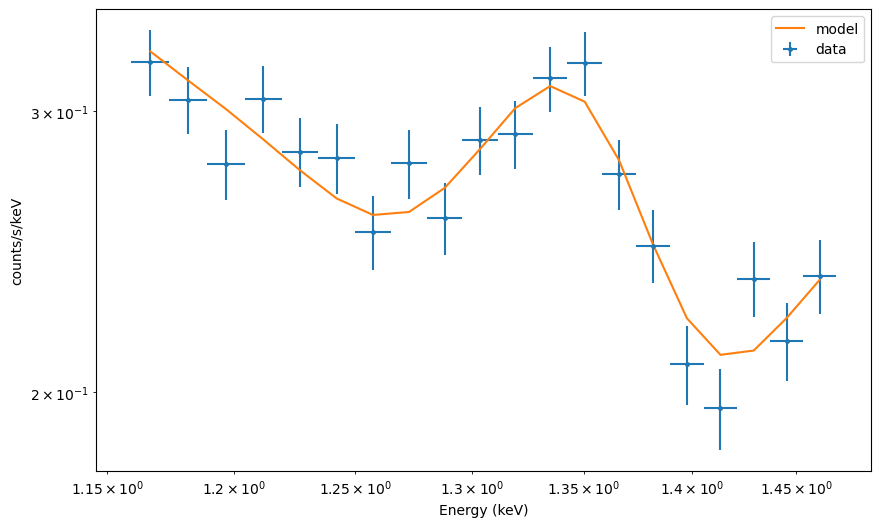

In [31]:
Plot.commands = ()
Plot.xAxis = "keV"
Plot("data")
#ax.clear()

fig, ax = plt.subplots(figsize=(10,6))
for plot_grp in range(1,len(vfilespectrum)+1):
    energies = np.asarray(Plot.x(plot_grp))
    edeltas = np.asarray(Plot.xErr(plot_grp))
    rates = np.asarray(Plot.y(plot_grp))
    errors = np.asarray(Plot.yErr(plot_grp))
    foldedmodel = np.asarray(Plot.model(plot_grp))
    ax.errorbar(energies, rates, xerr=edeltas,yerr=errors,fmt='.',markersize='5',label='data')
    ax.plot(energies, foldedmodel,label='model')

#ax.axhline(y=10)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

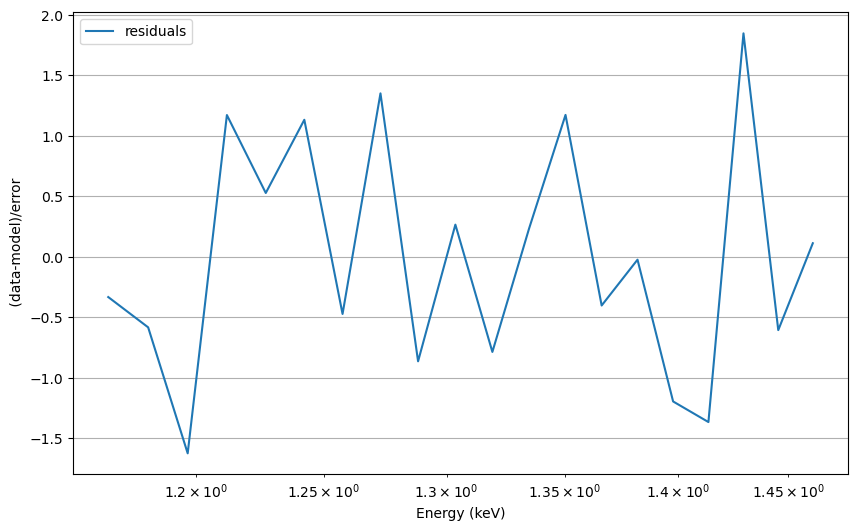

In [32]:
ax.clear()

fig, ax = plt.subplots(figsize=(10,6))
for plot_grp in range(1,len(vfilespectrum)+1):
    energies = np.asarray(Plot.x(plot_grp))
    edeltas = np.asarray(Plot.xErr(plot_grp))
    rates = np.asarray(Plot.y(plot_grp))
    errors = np.asarray(Plot.yErr(plot_grp))
    foldedmodel = np.asarray(Plot.model(plot_grp))
    ax.plot(energies,(rates-foldedmodel)/errors,label='residuals')
#ax.axhline(y=-3)
#ax.axhline(y=3)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r' (data-model)/error')
ax.set_xscale("log")
#ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

Plot command list is now empty
nAddComps  4
0
1
3


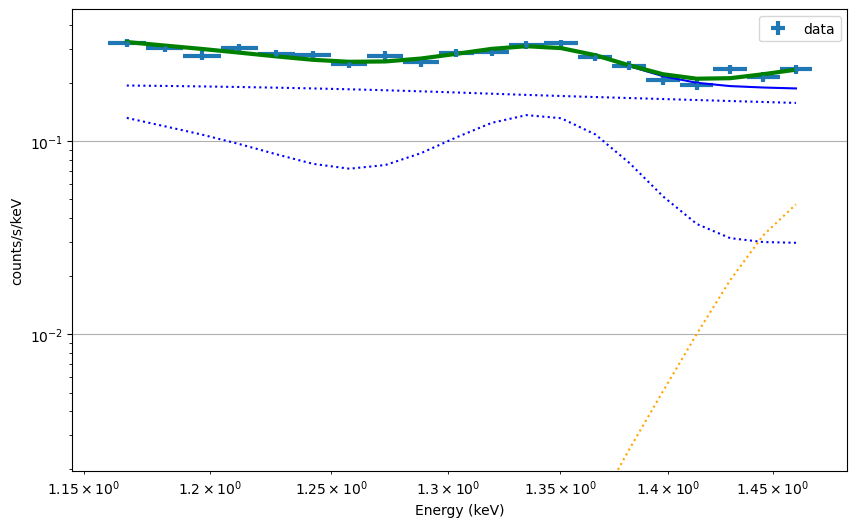

In [33]:
# VALID WHEN I HAVE TABS (MULTIPLICATIVE MODEL)

Plot.commands = ()
Plot.add = True
Plot.xAxis = "keV"
Plot("ldata")

# FIX THE TM to plot starting from 1
plot_grp = 1
energiesTMi = np.asarray(Plot.x(plot_grp))
edeltasTMi = np.asarray(Plot.xErr(plot_grp))
ratesTMi = np.asarray(Plot.y(plot_grp))
errorsTMi = np.asarray(Plot.yErr(plot_grp))
foldedmodel = np.asarray(Plot.model(plot_grp))
nAddComps = int(Plot.nAddComps(plot_grp))
print("nAddComps ",nAddComps)

modelcomp = np.zeros((nAddComps, len(energiesTMi)))
modelcomptot = np.zeros(len(energiesTMi))

for i in range(0,nAddComps):
    plot_grp = i + 1 # so that it starts with 1
    #print(i,plot_grp)
    modelcomp[i] = np.asarray(Plot.addComp(plot_grp))
    modelcomptot = modelcomptot + modelcomp[i]

fig, ax = plt.subplots(figsize=(10,6))
ax.errorbar(energiesTMi, ratesTMi, xerr=edeltasTMi,yerr=errorsTMi,fmt='.',markersize='5',label='data',linewidth=3.0)
#ax.plot(energiesTMi, foldedmodel,label='model')
#ax.plot(energiesTMi, modelcomptot,label='model2',linestyle='-', marker='',color='green',linewidth=3.0)

# start_index_astrol is where astro lines start
# -1 because no DM -1 because TAbs is just multiplicative -1 because index i start from 0
index_cont = start_index_astrol-3
model_cont = np.zeros(len(energiesTMi))
for i in range(0,index_cont):
    model_cont = model_cont + modelcomp[i][:]

# Single continous comp
for i in range(0,index_cont):
    print(i)
    ax.plot(energiesTMi, modelcomp[i][:],label='',linestyle=':', marker='',color='blue')

# total continous comp
ax.plot(energiesTMi, model_cont,label='',linestyle='-', marker='',color='blue')


#DM
ax.plot(energiesTMi, modelcomp[index_cont][:],label='',linestyle=':', marker='',color='black')

#Astro lines
for i in range(index_cont+1,nAddComps):
    print(i)
    ax.plot(energiesTMi, modelcomp[i][:],label='',linestyle=':', marker='',color='orange')

ax.plot(energiesTMi, modelcomptot,label='',linestyle='-', marker='',color='green',linewidth=3.0)



ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(np.min(ratesTMi)*0.01,np.max(ratesTMi)*1.5)
ax.grid()
ax.legend()


#data = np.column_stack([energies,modelcomp[1][:], modelcomp[2][:], modelcomp[3][:]])
#datafile_path = "AstroComponents_APEC_APEC_PL.txt"
#np.savetxt(datafile_path , data) #fmt=['%6.2f','%6.2f', '%.2f', '%10.2f', '%10.2f']


In [34]:
print(modelcomp[0][:])
print(modelcomp[1][:])

[0.13226589 0.11974903 0.10831367 0.09678809 0.08572296 0.07647428
 0.07217762 0.07540826 0.08690193 0.1049331  0.1246739  0.13674902
 0.13178347 0.10857626 0.07724598 0.05175646 0.03733483 0.03153723
 0.03010174 0.0298319 ]
[0.19464366 0.19370953 0.19257379 0.19124172 0.18971306 0.18799823
 0.18608291 0.1839596  0.18161822 0.17910451 0.17653355 0.17405259
 0.17176196 0.16964769 0.16763253 0.16565895 0.16370391 0.16179672
 0.15996954 0.15815252]


NOW FIT ASTRO + DM

In [35]:
# Change DM norm and T/F
change_keyfits(params_name, params_target, keyfits, "gaussian", "norm", True)
change_param_value(params, params_name, params_target, "gaussian", "norm", normline_start)

# set the other parameters to their best-fit value of previous fit
for val, name, attr in zip(params_astro, params_name_fit, params_target_fit):
    change_param_value(params, params_name, params_target, name, attr, val)    

# since you have changed norm and key(True/False), update XSpec
mymodel_all.set_values_all(params, lowers, uppers)
mymodel_all.set_frozen(keyfits)

# Select the parameters to Fit. You can check that DM is present
params_fit, bounds_fit, params_name_fit, params_target_fit, keyfits_fit = paramfit(params, lowers, uppers, params_name, params_target, keyfits)

In [36]:
printparam(params_fit, bounds_fit[:,0],bounds_fit[:,1], params_name_fit, params_target_fit, keyfits_fit)

TBabs   nH   0.2959258347308061   0.0063   0.7   True
apec   kT   0.39170107232417395   0.023   8.0   True
apec   norm   0.2071848899967829   0.0   8.5   True
powerlaw   PhoIndex   2.020732190435901   -5.0   5.0   True
powerlaw   norm   0.11847293012600633   0.0   50.0   True
gaussian   norm   6.27892380797356e-05   0.0   0.6278923807973559   True
gaussian_5   norm   0.00128081718337422   0.0   0.6278923807973559   True
gaussian_5   LineE   1.4775014337760848   1.47   1.5   True


In [37]:
Xset.chatter = 10
AllModels.show()
Xset.chatter = 1


Parameters defined:
Model mpoly:TBabs<1>(apec<2> + powerlaw<3> + gaussian<4>) + gaussian<5> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   TBabs      nH         10^22    0.295926     +/-  0.439201     
   2    2   apec       kT         keV      0.391701     +/-  0.393714     
   3    2   apec       Abundanc            1.00000      frozen
   4    2   apec       Redshift            0.0          frozen
   5    2   apec       norm                0.207185     +/-  0.477013     
   6    3   powerlaw   PhoIndex            2.02073      +/-  2.32929      
   7    3   powerlaw   norm                0.118473     +/-  0.135431     
   8    4   gaussian   LineE      keV      1.31200      frozen
   9    4   gaussian   Sigma      keV      9.62133E-04  frozen
  10    4   gaussian   norm                6.27892E-05  +/-  0.0          
  11    5   gaussian   LineE      keV      1.47750      +/-  6.49181E-02  
  12    5   gaussian   Sigma      keV      1

Peform fit

In [38]:
params_all,TS_all, pvalue_all, dof_all, nfit_all = doFit(fullmodel_xp, params_fit, bounds_fit, params_name_fit, params_target_fit, TypeFit)
#
print("Test Statistics ",TS_all," testStatistics ",TS_all," dof ",dof_all," nVarPars ",nfit_all)
print("pvalue ",pvalue_all)
print(params_all)
print(params_name_fit)
print(params_target_fit)
#
# Save DM normalization
DMbf = return_param_value(params_all, params_name_fit, params_target_fit, "gaussian", "norm")
print("DM bf ",DMbf)
print("DeltaTS ",TS_astro-TS_all)

Test Statistics  18.272041321557463  testStatistics  18.272041321557463  dof  12  nVarPars  8
pvalue  0.1116122231
[2.96000009e-01 3.91631408e-01 2.06572353e-01 2.02120628e+00
 1.18176856e-01 6.46006003e-05 1.28044363e-03 1.47731601e+00]
['TBabs' 'apec' 'apec' 'powerlaw' 'powerlaw' 'gaussian' 'gaussian_5'
 'gaussian_5']
['nH' 'kT' 'norm' 'PhoIndex' 'norm' 'norm' 'norm' 'LineE']
DM bf  6.460060026884311e-05
DeltaTS  0.07242658822573844


In [39]:
printparam(params_all, bounds_fit[:,0],bounds_fit[:,1], params_name_fit, params_target_fit, keyfits_fit)

TBabs   nH   0.29600000922463254   0.0063   0.7   True
apec   kT   0.3916314084107116   0.023   8.0   True
apec   norm   0.20657235318142236   0.0   8.5   True
powerlaw   PhoIndex   2.0212062783946796   -5.0   5.0   True
powerlaw   norm   0.11817685554911075   0.0   50.0   True
gaussian   norm   6.460060026884311e-05   0.0   0.6278923807973559   True
gaussian_5   norm   0.001280443627386585   0.0   0.6278923807973559   True
gaussian_5   LineE   1.4773160148513245   1.47   1.5   True


In [40]:
Xset.chatter = 10
AllModels.show()
Xset.chatter = 1


Parameters defined:
Model mpoly:TBabs<1>(apec<2> + powerlaw<3> + gaussian<4>) + gaussian<5> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   TBabs      nH         10^22    0.296000     +/-  0.768982     
   2    2   apec       kT         keV      0.391631     +/-  0.480101     
   3    2   apec       Abundanc            1.00000      frozen
   4    2   apec       Redshift            0.0          frozen
   5    2   apec       norm                0.206572     +/-  0.681662     
   6    3   powerlaw   PhoIndex            2.02121      +/-  3.76312      
   7    3   powerlaw   norm                0.118177     +/-  0.227918     
   8    4   gaussian   LineE      keV      1.31200      frozen
   9    4   gaussian   Sigma      keV      9.62133E-04  frozen
  10    4   gaussian   norm                6.46006E-05  +/-  6.29473E-04  
  11    5   gaussian   LineE      keV      1.47732      +/-  7.03802E-02  
  12    5   gaussian   Sigma      keV      1

In [41]:
Xset.chatter = 10
Fit.show()
Xset.chatter = 1


Fit statistic  : C-Statistic                   18.27     using 20 bins.

Test statistic : Chi-Squared                   18.14     using 20 bins.
 Null hypothesis probability of 1.12e-01 with 12 degrees of freedom


In [42]:
print("TS ",Fit.statistic)

TS  18.272041321557463


Plot command list is now empty


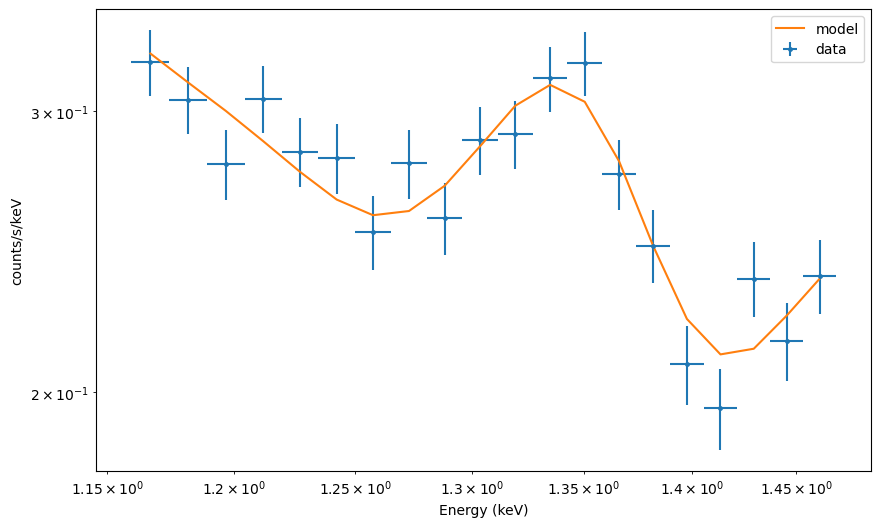

In [43]:
Plot.commands = ()
Plot.xAxis = "keV"
Plot("data")
#ax.clear()

fig, ax = plt.subplots(figsize=(10,6))
for plot_grp in range(1,len(vfilespectrum)+1):
    energies = np.asarray(Plot.x(plot_grp))
    edeltas = np.asarray(Plot.xErr(plot_grp))
    rates = np.asarray(Plot.y(plot_grp))
    errors = np.asarray(Plot.yErr(plot_grp))
    foldedmodel = np.asarray(Plot.model(plot_grp))
    ax.errorbar(energies, rates, xerr=edeltas,yerr=errors,fmt='.',markersize='5',label='data')
    ax.plot(energies, foldedmodel,label='model')

#ax.axhline(y=10)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

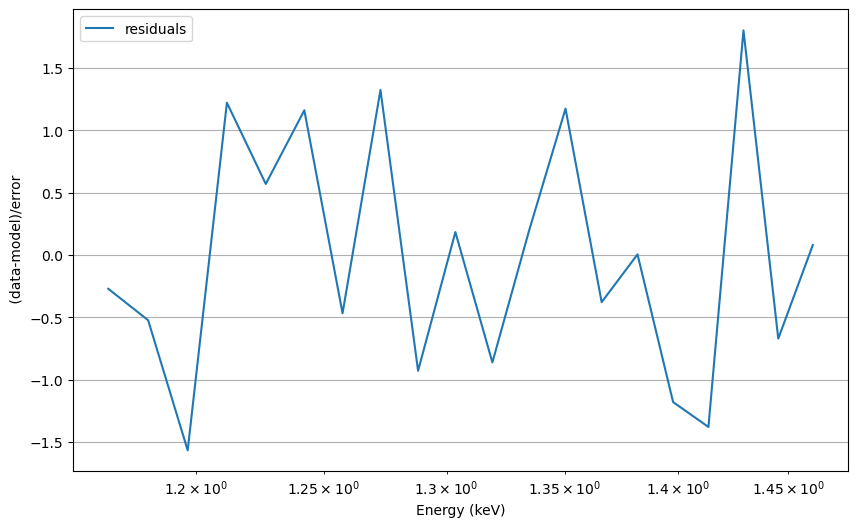

In [44]:
ax.clear()

fig, ax = plt.subplots(figsize=(10,6))
for plot_grp in range(1,len(vfilespectrum)+1):
    energies = np.asarray(Plot.x(plot_grp))
    edeltas = np.asarray(Plot.xErr(plot_grp))
    rates = np.asarray(Plot.y(plot_grp))
    errors = np.asarray(Plot.yErr(plot_grp))
    foldedmodel = np.asarray(Plot.model(plot_grp))
    ax.plot(energies,(rates-foldedmodel)/errors,label='residuals')
#ax.axhline(y=-3)
#ax.axhline(y=3)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r' (data-model)/error')
ax.set_xscale("log")
#ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

Plot command list is now empty
nAddComps  4
0
1
3


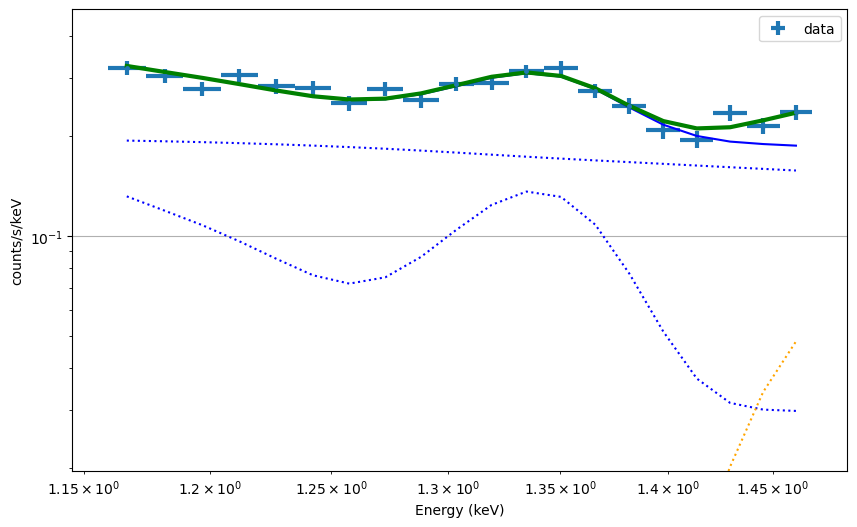

In [45]:
# VALID WHEN I HAVE TABS (MULTIPLICATIVE MODEL)

Plot.commands = ()
Plot.add = True
Plot.xAxis = "keV"
Plot("ldata")

# FIX THE TM to plot starting from 1
plot_grp = 1
energiesTMi = np.asarray(Plot.x(plot_grp))
edeltasTMi = np.asarray(Plot.xErr(plot_grp))
ratesTMi = np.asarray(Plot.y(plot_grp))
errorsTMi = np.asarray(Plot.yErr(plot_grp))
foldedmodel = np.asarray(Plot.model(plot_grp))
nAddComps = int(Plot.nAddComps(plot_grp))
print("nAddComps ",nAddComps)

modelcomp = np.zeros((nAddComps, len(energiesTMi)))
modelcomptot = np.zeros(len(energiesTMi))

for i in range(0,nAddComps):
    plot_grp = i + 1 # so that it starts with 1
    #print(i,plot_grp)
    modelcomp[i] = np.asarray(Plot.addComp(plot_grp))
    modelcomptot = modelcomptot + modelcomp[i]

fig, ax = plt.subplots(figsize=(10,6))
ax.errorbar(energiesTMi, ratesTMi, xerr=edeltasTMi,yerr=errorsTMi,fmt='.',markersize='5',label='data',linewidth=3.0)
#ax.plot(energiesTMi, foldedmodel,label='model')
#ax.plot(energiesTMi, modelcomptot,label='model2',linestyle='-', marker='',color='green',linewidth=3.0)

# start_index_astrol is where astro lines start
# -1 because no DM -1 because TAbs is just multiplicative -1 because index i start from 0
index_cont = start_index_astrol-3
model_cont = np.zeros(len(energiesTMi))
for i in range(0,index_cont):
    model_cont = model_cont + modelcomp[i][:]

# Single continous comp
for i in range(0,index_cont):
    print(i)
    ax.plot(energiesTMi, modelcomp[i][:],label='',linestyle=':', marker='',color='blue')

# total continous comp
ax.plot(energiesTMi, model_cont,label='',linestyle='-', marker='',color='blue')


#DM
ax.plot(energiesTMi, modelcomp[index_cont][:],label='',linestyle=':', marker='',color='black')

#Astro lines
for i in range(index_cont+1,nAddComps):
    print(i)
    ax.plot(energiesTMi, modelcomp[i][:],label='',linestyle=':', marker='',color='orange')

ax.plot(energiesTMi, modelcomptot,label='',linestyle='-', marker='',color='green',linewidth=3.0)



ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(np.min(ratesTMi)*0.1,np.max(ratesTMi)*1.5)
ax.grid()
ax.legend()


#data = np.column_stack([energies,modelcomp[1][:], modelcomp[2][:], modelcomp[3][:]])
#datafile_path = "AstroComponents_APEC_APEC_PL.txt"
#np.savetxt(datafile_path , data) #fmt=['%6.2f','%6.2f', '%.2f', '%10.2f', '%10.2f']


In [46]:
print(modelcomp[0][:])
print(modelcomp[1][:])

[0.13181429 0.11933843 0.10794185 0.09645643 0.08543008 0.07621379
 0.07193236 0.07515238 0.08660718 0.10457721 0.12425097 0.136285
 0.13133627 0.10820802 0.0769844  0.05158141 0.03720806 0.03142872
 0.02999628 0.02972591]
[0.19411846 0.1931865  0.19205345 0.19072458 0.18919963 0.18748901
 0.1855784  0.18346032 0.18112473 0.17861724 0.17605264 0.17357782
 0.17129288 0.16918386 0.16717373 0.16520507 0.16325491 0.16135246
 0.15952979 0.15771725]


Perform an approximate profiling

In [47]:
TSth = 2.71
def MTroots(vx,vy):
    vroots = []
    for i in range(1,len(vx)):
        #print("vx ",vx[i]," ",vy[i])
        #Check whether sign has changed
        if(vy[i]*vy[i-1]<0.):
            root=(vx[i]*vy[i-1]-vx[i-1]*vy[i])/(vy[i-1]-vy[i])
            #print(vx[i-1]," ",vx[i]," ",vy[i-1]," ",vy[i])
            #print("i ", i," ",root," ")
            vroots.append(root)
    return  vroots

def chi2approx(fullmodel_xp, params_fit, params_name_fit, params_target_fit, A):
    # Change DM normalization
    params_inside = params_fit
    change_param_value(params_inside, params_name_fit, params_target_fit, "gaussian", "norm", A)
    Fit.statMethod = "cstat"  # fitting statistics = Cash-statistics
    mymodel_fit = MTmodel(fullmodel_xp, params_name_fit, params_target_fit, Fit)
    # evaluation
    res = mymodel_fit.evaluate_folded(params_inside)
    return res

def ApproximateBound(model_final, DMbf, normlDMhdata2, nstepsDM, TS_all, params_fit, params_name_fit, params_target_fit):
    start = np.max(np.array([DMbf,normlDMhdata2*1e-5]))
    end = normlDMhdata2
    profile_range = np.logspace(np.log10(start), np.log10(end), num = nstepsDM)
    TS_vals = np.zeros_like(profile_range)
    for i, A in enumerate(profile_range):
        TS_vals[i] = chi2approx(model_final, params_fit, params_name_fit, params_target_fit, A)
        #print("A TS ",A," ",TS_vals[i])
    x = np.log10(profile_range)
    y = TS_vals - TS_all - TSth
    vroots = np.pow(10.,MTroots(x,y))
    if(len(vroots)>0):
        bound_approx=np.max(vroots)
    else:
        bound_approx=0.
    return bound_approx

def BoundProfiling(profile_range, delta_TS):
    x = np.log10(profile_range)
    y = delta_TS - TSth
    vroots = np.pow(10.,MTroots(x,y))
    if(len(vroots)>0):
        bound=np.max(vroots)
    else:
        bound=0.
    return bound

In [48]:
# set the parameters to their best-fit value of previous fit with DM
for val, name, attr in zip(params_all, params_name_fit, params_target_fit):
    change_param_value(params, params_name, params_target, name, attr, val)  

# since you have changed norm update XSpec 
mymodel_all.set_values_all(params, lowers, uppers)

# Select the parameters to Fit. You can check that DM is still present
params_fit, bounds_fit, params_name_fit, params_target_fit, keyfits_fit = paramfit(params, lowers, uppers, params_name, params_target, keyfits)

printparam(params_fit, bounds_fit[:,0],bounds_fit[:,1], params_name_fit, params_target_fit, keyfits_fit)

TBabs   nH   0.29600000922463254   0.0063   0.7   True
apec   kT   0.3916314084107116   0.023   8.0   True
apec   norm   0.20657235318142236   0.0   8.5   True
powerlaw   PhoIndex   2.0212062783946796   -5.0   5.0   True
powerlaw   norm   0.11817685554911075   0.0   50.0   True
gaussian   norm   6.460060026884311e-05   0.0   0.6278923807973559   True
gaussian_5   norm   0.001280443627386585   0.0   0.6278923807973559   True
gaussian_5   LineE   1.4773160148513245   1.47   1.5   True


In [49]:
Xset.chatter = 10
AllModels.show()
Xset.chatter = 1


Parameters defined:
Model mpoly:TBabs<1>(apec<2> + powerlaw<3> + gaussian<4>) + gaussian<5> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   TBabs      nH         10^22    0.296000     +/-  0.768982     
   2    2   apec       kT         keV      0.391631     +/-  0.480101     
   3    2   apec       Abundanc            1.00000      +/-  0.0          
   4    2   apec       Redshift            0.0          +/-  0.0          
   5    2   apec       norm                0.206572     +/-  0.681662     
   6    3   powerlaw   PhoIndex            2.02121      +/-  3.76312      
   7    3   powerlaw   norm                0.118177     +/-  0.227918     
   8    4   gaussian   LineE      keV      1.31200      +/-  0.0          
   9    4   gaussian   Sigma      keV      9.62133E-04  +/-  0.0          
  10    4   gaussian   norm                6.46006E-05  +/-  6.29473E-04  
  11    5   gaussian   LineE      keV      1.47732      +/-  7.03802E-0

In [50]:
# #### Approximate bound: PASS ARRAYS _all referring to best fit model
nstepsDM = 100 # can be a bit larger since it just a matter of evaluations
bound_approx = ApproximateBound(fullmodel_xp, DMbf, normlDMhdata2, nstepsDM, TS_all, params_fit, params_name_fit, params_target_fit)
print("Approximate bound ",bound_approx)

Approximate bound  0.00046755096907435777


Proper profiling

In [51]:
# set the parameters to their best-fit value of global fit with DM (also norm DM)
for val, name, attr in zip(params_all, params_name_fit, params_target_fit):
    change_param_value(params, params_name, params_target, name, attr, val)  

# Change DM  T/F setting to F
change_keyfits(params_name, params_target, keyfits, "gaussian", "norm", False)


# since you have changed norm and key(True/False), update XSpec
mymodel_all.set_values_all(params, lowers, uppers)
mymodel_all.set_frozen(keyfits)

# Parameters should be at bf value of fit Astro+DM. Simple check that evaluations gives correct TS
print("TS now ",mymodel_all.evaluate_folded(params)," TS_all ",TS_all)
print("*****************")

# Select the parameters to Fit. You can check that DM is not present
params_fit, bounds_fit, params_name_fit, params_target_fit, keyfits_fit = paramfit(params, lowers, uppers, params_name, params_target, keyfits)

printparam(params_fit, bounds_fit[:,0],bounds_fit[:,1], params_name_fit, params_target_fit, keyfits_fit)

TS now  18.272041321557463  TS_all  18.272041321557463
*****************
TBabs   nH   0.29600000922463254   0.0063   0.7   True
apec   kT   0.3916314084107116   0.023   8.0   True
apec   norm   0.20657235318142236   0.0   8.5   True
powerlaw   PhoIndex   2.0212062783946796   -5.0   5.0   True
powerlaw   norm   0.11817685554911075   0.0   50.0   True
gaussian_5   norm   0.001280443627386585   0.0   0.6278923807973559   True
gaussian_5   LineE   1.4773160148513245   1.47   1.5   True


In [52]:
Xset.chatter = 10
AllModels.show()
Xset.chatter = 1


Parameters defined:
Model mpoly:TBabs<1>(apec<2> + powerlaw<3> + gaussian<4>) + gaussian<5> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   TBabs      nH         10^22    0.296000     +/-  0.768982     
   2    2   apec       kT         keV      0.391631     +/-  0.480101     
   3    2   apec       Abundanc            1.00000      frozen
   4    2   apec       Redshift            0.0          frozen
   5    2   apec       norm                0.206572     +/-  0.681662     
   6    3   powerlaw   PhoIndex            2.02121      +/-  3.76312      
   7    3   powerlaw   norm                0.118177     +/-  0.227918     
   8    4   gaussian   LineE      keV      1.31200      frozen
   9    4   gaussian   Sigma      keV      9.62133E-04  frozen
  10    4   gaussian   norm                6.46006E-05  frozen
  11    5   gaussian   LineE      keV      1.47732      +/-  7.03802E-02  
  12    5   gaussian   Sigma      keV      1.00000E-04  

In [53]:
# Just some recap of some relevant quantities along the notebook
print("Test Statistics Astro ",TS_astro," testStatistics ",TS_astro," dof ",dof_astro," nVarPars ",nfit_astro," bins ",dof_astro+nfit_astro)
print("pvalue ",pvalue_astro)
print("*********")
print("Test Statistics All ",TS_all," testStatistics ",TS_all," dof ",dof_all," nVarPars ",nfit_all," bins ",dof_all+nfit_all)
print("pvalue ",pvalue_all)
print("Delta TS ",TS_astro-TS_all)
print("*********")
print("bound_approx", bound_approx)

Test Statistics Astro  18.3444679097832  testStatistics  18.3444679097832  dof  13  nVarPars  7  bins  20
pvalue  0.1499132292
*********
Test Statistics All  18.272041321557463  testStatistics  18.272041321557463  dof  12  nVarPars  8  bins  20
pvalue  0.1116122231
Delta TS  0.07242658822573844
*********
bound_approx 0.00046755096907435777


In [54]:
print("bound_approx", bound_approx)
print("DM bf ",DMbf," normlDMhdata2 ",normlDMhdata2)
print("*******************************")
nstepsDM = 10
start = bound_approx/10.
end = bound_approx*100
profile_range = np.logspace(np.log10(start), np.log10(end), num = nstepsDM)
TS_vals = np.zeros_like(profile_range)
for i, A in enumerate(profile_range):
        #set DM norm
        fullmodel_xp.gaussian.norm = A
        params_inside,TS_inside, pvalue_inside, dof_inside, nfit_inside = doFit(fullmodel_xp, params_fit, bounds_fit, params_name_fit, params_target_fit, TypeFit)
        TS_vals[i] = TS_inside
        # update params to new best fit if you want
        # otherwise you are always giving the parameters of bf model with DM
        #params_fit = params_inside
        print(i, A, TS_vals[i], TS_vals[i] - TS_all)
        if  i >= 2 and TS_vals[i] - TS_all > 150:
            profile_range = profile_range[:i+1]
            TS_vals = TS_vals[:i+1]
            break

bound_approx 0.00046755096907435777
DM bf  6.460060026884311e-05  normlDMhdata2  0.006278923807973559
*******************************
0 4.675509690743583e-05 18.281105126126285 0.00906380456882161
1 0.00010073080271318212 18.268145975944563 -0.0038953456129000585
2 0.00021701793572003744 18.22731825093163 -0.044723070625831696
3 0.00046755096907435826 17.266282434737683 -1.0057588868197804
4 0.0010073080271318213 19.75233784172665 1.480296520169187
5 0.002170179357200372 29.10582978153718 10.833788459979719
6 0.004675509690743578 69.73088297065189 51.458841649094424
7 0.010073080271318213 251.17231586508316 232.9002745435257


In [55]:
#print(profile_range)
#fullmodel_xp.gaussian.norm = 2.03298971e-02
#print(fullmodel_xp.gaussian.norm.values)
#print("TS ",Fit.statistic)

In [56]:
#params_inside,TS_inside, pvalue_inside, dof_inside, nfit_inside = doFit(fullmodel_xp, params_fit, bounds_fit, params_name_fit, params_target_fit, TypeFit)
#print(i, A, TS_inside)

In [57]:
deltaTS_vals = TS_vals - TS_all
A_95 = BoundProfiling(profile_range, deltaTS_vals)
print("bound_approx", bound_approx)
print("A_95 ",A_95)
#
# Check how really close you are to DeltaTS = 2.71
#
fullmodel_xp.gaussian.norm = A_95
params_inside, TS_inside, pvalue_inside, dof_inside, nfit_inside = doFit(
    fullmodel_xp, params_fit, bounds_fit, params_name_fit, params_target_fit, TypeFit
)
print("Initial A_95 ", A_95, " DeltaTS ", TS_inside-TS_all)

bound_approx 0.00046755096907435777
A_95  0.0011142576498544736
Initial A_95  0.0011142576498544736  DeltaTS  2.1377200730818906


In [58]:
# Refine a bit more
factor = 1.5  # Range: A_95_refined / 2 to A_95_refined * 2
profile_range_fine = np.logspace(
    np.log10(A_95 / factor),
    np.log10(A_95 * factor),
    num=10
)
TS_vals_fine = np.zeros_like(profile_range_fine)
#
# notice that _fit has not been changed and their are set to the astro+DM best fit values
#
for i, A in enumerate(profile_range_fine):
    fullmodel_xp.gaussian.norm = A
    params_inside, TS_inside, pvalue_inside, dof_inside, nfit_inside = doFit(
        fullmodel_xp, params_fit, bounds_fit, params_name_fit, params_target_fit, TypeFit
    )
    TS_vals_fine[i] = TS_inside
    # params_fit = params_inside
    print("[REFINED]", i, A, TS_vals_fine[i], TS_vals_fine[i] - TS_all)
#
profile_range = np.concatenate([profile_range, profile_range_fine])
TS_vals = np.concatenate([TS_vals, TS_vals_fine])
sort_idx = np.argsort(profile_range)
profile_range = profile_range[sort_idx]
TS_vals = TS_vals[sort_idx]
deltaTS_vals = TS_vals - TS_all
#
A_95 = BoundProfiling(profile_range, deltaTS_vals)
#
fullmodel_xp.gaussian.norm = A_95
params_inside, TS_inside, pvalue_inside, dof_inside, nfit_inside = doFit(
    fullmodel_xp, params_fit, bounds_fit, params_name_fit, params_target_fit, TypeFit
)
print("Final A_95 ", A_95, " DeltaTS ", TS_inside-TS_all)

[REFINED] 0 0.0007428384332363155 18.565792666704496 0.29375134514703305
[REFINED] 1 0.0008128787232500062 18.68769527771839 0.41565395616092715
[REFINED] 2 0.0008895229287394065 19.087286540395354 0.8152452188378909
[REFINED] 3 0.0009733937155958475 19.557355656887133 1.2853143353296694
[REFINED] 4 0.001065172459246484 20.124592087301366 1.8525507657439029
[REFINED] 5 0.0011656047802226471 20.743882954953193 2.47184163339573
[REFINED] 6 0.001275506601662419 21.461301052185966 3.1892597306285033
[REFINED] 7 0.0013957707779592755 22.22130873082569 3.949267409268227
[REFINED] 8 0.0015273743484086266 23.18845018364462 4.916408862087156
[REFINED] 9 0.0016713864747817107 24.344431913723493 6.07239059216603
Final A_95  0.0012009961313357437  DeltaTS  2.7126821081239783


Plot command list is now emptympoly::gaussian:LineE>
nAddComps  4
0
1
3


***Error: Desired Value 0.00128044 is outside hard range 1.47 - 1.5


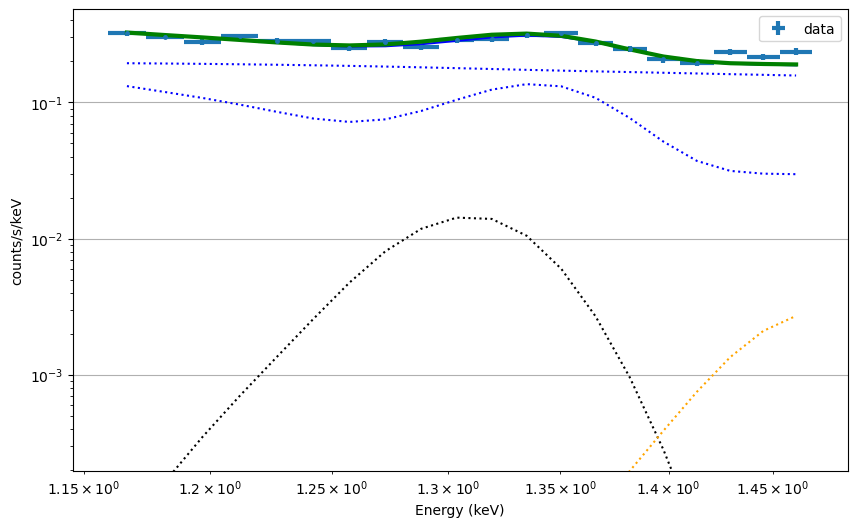

In [59]:
# set the parameters to their best-fit value of global fit with DM (also norm DM)
for val, name, attr in zip(params_all, params_name_fit, params_target_fit):
    change_param_value(params, params_name, params_target, name, attr, val)  

# Change DM  T/F setting to F
change_keyfits(params_name, params_target, keyfits, "gaussian", "norm", False)
change_param_value(params, params_name, params_target, "gaussian", "norm", bound_approx)

# since you have changed norm and key(True/False), update XSpec
mymodel_all.set_values_all(params, lowers, uppers)
mymodel_all.set_frozen(keyfits)


# VALID WHEN I HAVE TABS (MULTIPLICATIVE MODEL)

Plot.commands = ()
Plot.add = True
Plot.xAxis = "keV"
Plot("ldata")

# FIX THE TM to plot starting from 1
plot_grp = 1
energiesTMi = np.asarray(Plot.x(plot_grp))
edeltasTMi = np.asarray(Plot.xErr(plot_grp))
ratesTMi = np.asarray(Plot.y(plot_grp))
errorsTMi = np.asarray(Plot.yErr(plot_grp))
foldedmodel = np.asarray(Plot.model(plot_grp))
nAddComps = int(Plot.nAddComps(plot_grp))
print("nAddComps ",nAddComps)

modelcomp = np.zeros((nAddComps, len(energiesTMi)))
modelcomptot = np.zeros(len(energiesTMi))

for i in range(0,nAddComps):
    plot_grp = i + 1 # so that it starts with 1
    #print(i,plot_grp)
    modelcomp[i] = np.asarray(Plot.addComp(plot_grp))
    modelcomptot = modelcomptot + modelcomp[i]

fig, ax = plt.subplots(figsize=(10,6))
ax.errorbar(energiesTMi, ratesTMi, xerr=edeltasTMi,yerr=errorsTMi,fmt='.',markersize='5',label='data',linewidth=3.0)
#ax.plot(energiesTMi, foldedmodel,label='model')
#ax.plot(energiesTMi, modelcomptot,label='model2',linestyle='-', marker='',color='green',linewidth=3.0)

# start_index_astrol is where astro lines start
# -1 because no DM -1 because TAbs is just multiplicative -1 because index i start from 0
index_cont = start_index_astrol-3
model_cont = np.zeros(len(energiesTMi))
for i in range(0,index_cont):
    model_cont = model_cont + modelcomp[i][:]

# Single continous comp
for i in range(0,index_cont):
    print(i)
    ax.plot(energiesTMi, modelcomp[i][:],label='',linestyle=':', marker='',color='blue')

# total continous comp
ax.plot(energiesTMi, model_cont,label='',linestyle='-', marker='',color='blue')


#DM
ax.plot(energiesTMi, modelcomp[index_cont][:],label='',linestyle=':', marker='',color='black')

#Astro lines
for i in range(index_cont+1,nAddComps):
    print(i)
    ax.plot(energiesTMi, modelcomp[i][:],label='',linestyle=':', marker='',color='orange')

ax.plot(energiesTMi, modelcomptot,label='',linestyle='-', marker='',color='green',linewidth=3.0)



ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(np.min(ratesTMi)*0.001,np.max(ratesTMi)*1.5)
ax.grid()
ax.legend()


#data = np.column_stack([energies,modelcomp[1][:], modelcomp[2][:], modelcomp[3][:]])
#datafile_path = "AstroComponents_APEC_APEC_PL.txt"
#np.savetxt(datafile_path , data) #fmt=['%6.2f','%6.2f', '%.2f', '%10.2f', '%10.2f']


In [60]:
print(modelcomp[index_cont][:])

[7.21528471e-05 1.63603129e-04 3.48839404e-04 6.98302650e-04
 1.34558144e-03 2.56195484e-03 4.75363603e-03 8.08435299e-03
 1.18098232e-02 1.42641426e-02 1.39516702e-02 1.05011142e-02
 6.00883306e-03 2.68813274e-03 9.62540410e-04 2.81886234e-04
 6.86737992e-05 1.41380070e-05 2.49196704e-06 3.82687106e-07]
